WeightedGridProblem self-check passed.
Heuristic self-check passed.
Algorithm self-check passed.


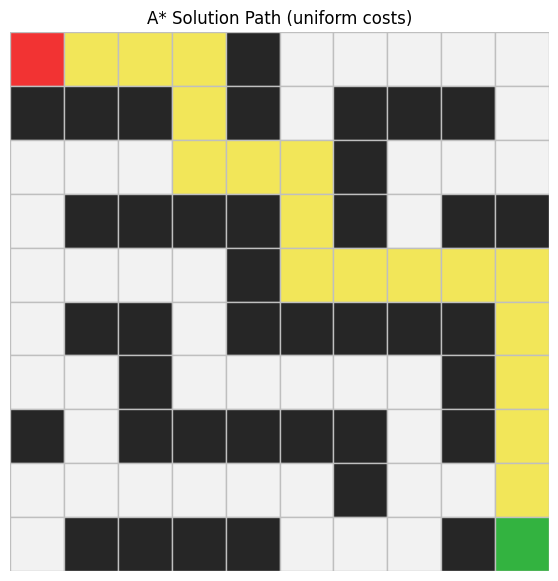

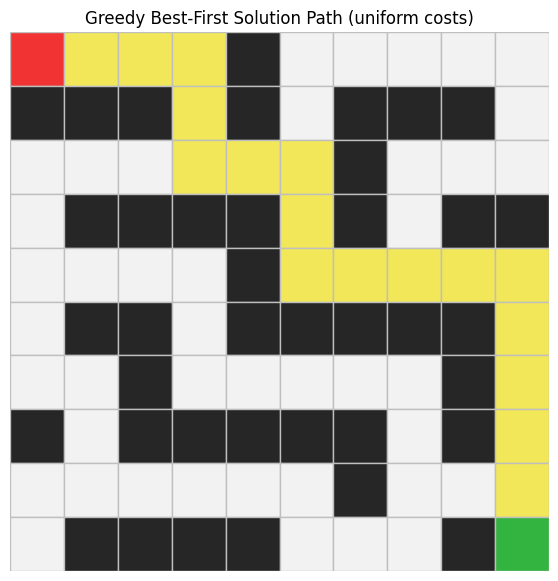

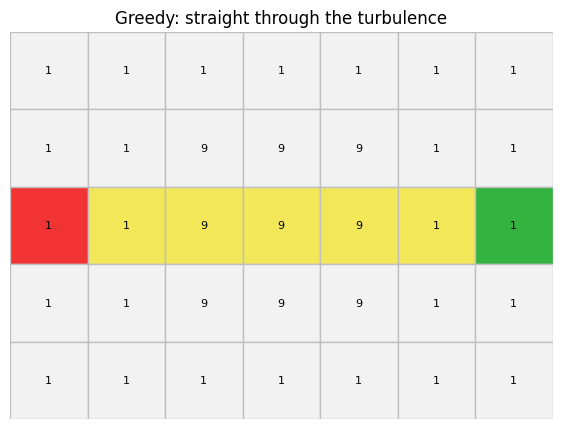

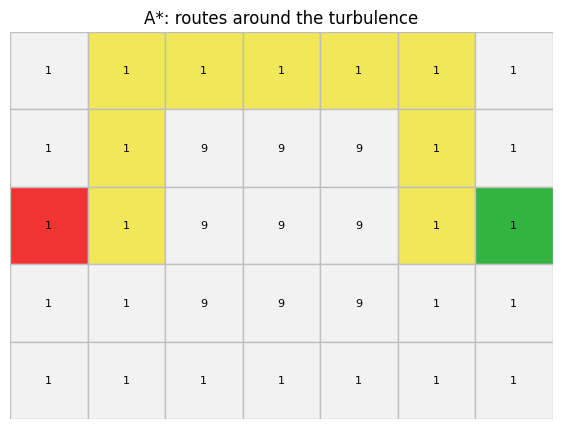

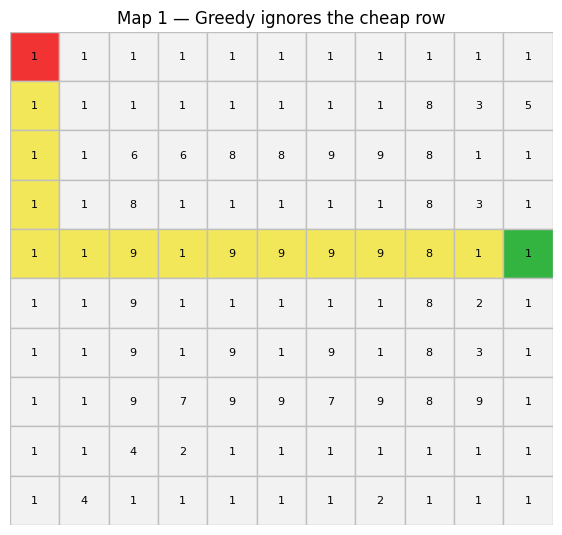

Greedy done


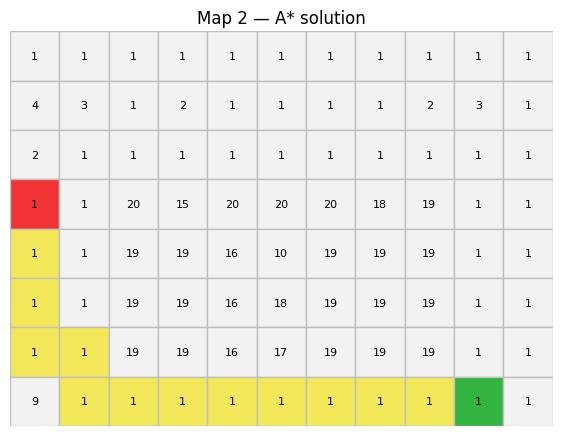

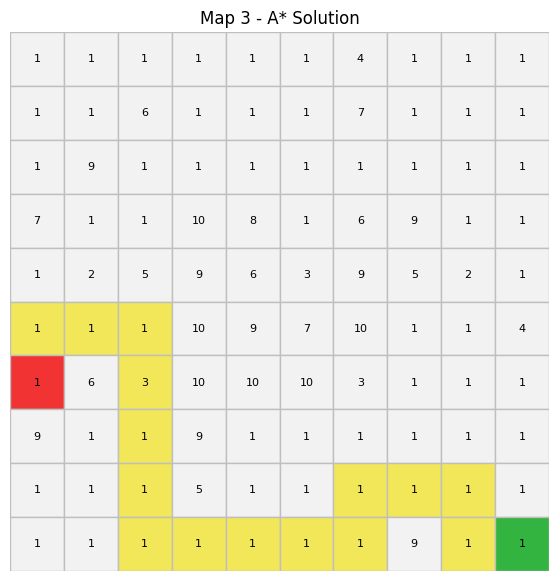

In [15]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost






def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])




MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        row, col = state
        legal_actions = []

        for action in MOVES:
            dr, dc = MOVES[action]
            neighbour_cell = (row + dr, col + dc)
            if self.in_bounds(neighbour_cell) and self.is_free(neighbour_cell):
                legal_actions.append(action)
        return legal_actions

        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
          row, col = state
          dr, dc = MOVES[action]
          return (row + dr, col + dc)

          raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")


class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        s = node.state
        for action in problem.actions(s):
          s_prime =  problem.result(s, action)
          cost = node.path_cost + problem.action_cost(s, action, s_prime)
          yield Node(state=s_prime, parent=node, action= action, path_cost=cost)


    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass



def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)


            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()





class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        row , col = next_state
        return self.terrain_costs[row][col]

        raise NotImplementedError("Complete WeightedGridProblem.action_cost")


wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")




def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)
    raise NotImplementedError("Complete manhattan_distance")



def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1 - r2)**2 + (c1 - c2)**2)

    raise NotImplementedError("Complete euclidean_distance")


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0



assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")



class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0



class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
      node = Node(state=problem.initial_state())
      frontier = PriorityQueue()
      frontier.push(self.evaluation(node, problem), node)
      reached = {problem.initial_state(): node}

      nodes_expanded = 0
      max_frontier_size = 1

      while frontier:
        node = frontier.pop()

        if problem.is_goal(node.state):
          return SearchResult(algorithm=self.algorithm_name,status="success",
                solution=node,nodes_expanded=nodes_expanded,max_frontier_size=max_frontier_size, )

        nodes_expanded += 1

        for child in self.expand(problem, node):
            s = child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
                reached[s] = child
                frontier.push(self.evaluation(child, problem), child)

        max_frontier_size = max(max_frontier_size, len(frontier))

      return SearchResult(algorithm=self.algorithm_name,status="failure",solution=None,nodes_expanded=nodes_expanded,max_frontier_size=max_frontier_size,)


class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return self.h(node, problem)

        raise NotImplementedError("Complete GreedyBestFirstSearch.evaluation")



class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:

        return self.h(node, problem) + node.path_cost

        raise NotImplementedError("Complete AStarSearch.evaluation")



class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost



class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.weight * self.h(node, problem)

        raise NotImplementedError("Complete WeightedAStarSearch.evaluation")


check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")


sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)


# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)


turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs)


turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

def inflated_heuristic(factor: float):
    def h(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
        return factor * manhattan_distance(state, goal)
    return h

    raise NotImplementedError("Complete inflated_heuristic")


mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)


class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def h(self, state, problem):
        return self.heuristic(state, problem.goal)

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        start = Node(state=problem.initial_state())
        limit = self.h(start.state, problem)

        nodes_expanded = 0
        max_frontier_size = 0
        iterations = []

        def state_is_on_path(state, node):
            while node is not None:
                if node.state == state:
                    return True
                node = node.parent
            return False

        def dfs(node, g, limit, depth):
            nonlocal nodes_expanded, max_frontier_size
            max_frontier_size = max(max_frontier_size, depth)

            f = g + self.h(node.state, problem)
            if f > limit:
                return None, f  # cutoff, report the f that exceeded

            if problem.is_goal(node.state):
                return node, f

            nodes_expanded += 1
            next_limit = math.inf

            for child in self.expand(problem, node):
                if state_is_on_path(child.state, node):
                    continue
                result, child_f = dfs(child, child.path_cost, limit, depth + 1)
                if result is not None:
                    return result, child_f
                next_limit = min(next_limit, child_f)

            return None, next_limit

        for i in range(max_iterations):
            result, next_limit = dfs(start, 0, limit, 1)

            if result is not None:
                iterations.append({"limit": limit, "outcome": "success"})
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=result,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    iterations=iterations,
                )

            if next_limit == math.inf:
                iterations.append({"limit": limit, "outcome": "failure"})
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="failure",
                    solution=None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    iterations=iterations,
                )

            iterations.append({"limit": limit, "outcome": "cutoff"})
            limit = next_limit

        return SearchResult(
            algorithm=self.algorithm_name,
            status="cutoff",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            iterations=iterations,
        )


# TODO 10:
# Create your first customer map here
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]


custom_costs_1 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 8, 3, 5],
    [1, 1, 6, 6, 8, 8, 9, 9, 8, 1, 1],
    [1, 1, 8, 1, 1, 1, 1, 1, 8, 3, 1],
    [1, 1, 9, 1, 9, 9, 9, 9, 8, 1, 1],
    [1, 1, 9, 1, 1, 1, 1, 1, 8, 2, 1],
    [1, 1, 9, 1, 9, 1, 9, 1, 8, 3, 1],
    [1, 1, 9, 7, 9, 9, 7, 9, 8, 9, 1],
    [1, 1, 4, 2, 1, 1, 1, 1, 1, 1, 1],
    [1, 4, 1, 1, 1, 1, 1, 2, 1, 1, 1],



]

custom_start_1 = (0, 0)
custom_goal_1 = (4, 10)


custom_problem_1 = WeightedGridProblem(
     custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
 )
custom_results_1 = [
     ucs.search(custom_problem_1),
     astar.search(custom_problem_1),
     wastar2.search(custom_problem_1),
     greedy.search(custom_problem_1),
 ]

show_results(custom_results_1)

plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[3].path, terrain_costs=custom_costs_1,
          title="Map 1 — Greedy ignores the cheap row")


# TODO 11:
# Create your second custom map here.
custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [4, 3, 1, 2, 1, 1, 1, 1, 2, 3, 1],
    [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 20, 15, 20, 20, 20, 18, 19, 1, 1],
    [1, 1, 19, 19, 16, 10, 19, 19, 19, 1, 1],
    [1, 1, 19, 19, 16, 18, 19, 19, 19, 1, 1],
    [1, 1, 19, 19, 16, 17, 19, 19, 19, 1, 1],
    [9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

custom_start_2 = (3,0)
custom_goal_2 = (7,9)

custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
 )

print("Greedy done")
custom_results_2 = [
     ucs.search(custom_problem_2),
     astar.search(custom_problem_2),
     wastar2.search(custom_problem_2),
     greedy.search(custom_problem_2),
]
show_results(custom_results_2)

plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[1].path, terrain_costs=custom_costs_2,
          title="Map 2 — A* solution")


# Grid 3

custom_grid_3 = [
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
]

custom_costs_3 = [
    [1, 1, 1, 1, 1, 1, 4, 1, 1, 1],
    [1, 1, 6, 1, 1, 1, 7, 1, 1, 1],
    [1, 9, 1, 1, 1, 1, 1, 1, 1, 1],
    [7, 1, 1, 10,8, 1, 6, 9, 1, 1],
    [1, 2, 5, 9, 6, 3, 9, 5, 2, 1],
    [1, 1, 1, 10,9 , 7,10,1, 1, 4],
    [1, 6, 3, 10,10,10, 3,1, 1, 1],
    [9, 1, 1, 9, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 5, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 9, 1, 1],
]

custom_start_3 = (6, 0)
custom_goal_3 = (9, 9)

custom_problem_3 = WeightedGridProblem(
    custom_grid_3,
    custom_start_3,
    custom_goal_3,
    terrain_costs=custom_costs_3
)

custom_results_3 = [
    ucs.search(custom_problem_3),
    astar.search(custom_problem_3),
    wastar2.search(custom_problem_3),
    greedy.search(custom_problem_3),
]
show_results(custom_results_3)


plot_path(
    custom_grid_3,
    start=custom_start_3,
    goal=custom_goal_3,
    path=custom_results_3[1].path,
    terrain_costs=custom_costs_3,
    title="Map 3 - A* Solution"
)


















Reflection Questions.
16.1
1. Heuristic Functions
h(n) estimates the straight-line distance in moving grom the start state to the goal state.

2.It allows the drone to fly over cells whether there is an obstacle or not.
The relaxed problem assumes that every cell cost 1 although cell have different cost values.

3. Manhattan has the larger admissible estimate, hence it sominates over eculidean distance.
Domination predicts that A* with Manhattan will expand fewer or equal nodes than A* with Euclidean. A bigger heuristic value pushes a node's f = g + h over the optimal cost sooner, so more nodes get pruned ,  meaning Manhattan guides the search more directly to the goal.

4.The Manhattan distance must not overestimate the true cost to reamin consistent and it is the number of moves it takes to reach a gaol state.  If every move cost atleast one then the true cost to reach the goal state would be atleast move count. If some cells are cost o.5 to enter, then the real cost will be less than the move count, which will cause the manhattam distance to overestimate the actual cost making it inadmissible.




16.2
1. Greedy ignores the g(n), it only focused on the nearest path to the goal. This made the Greedy best search incure several cost to get to the goal state compared to the A* and UCS.

2. The fewer nodes suggest that it didn`t explore alot of options to come up with the optimally best solution. Greeedy Optimizes only h(n), ignoring g(n), so it has no mechinsm to recognize that a path is actually expensive.

3 A drone being discharged to deliver equipments for an immediate sugery that needs to to be taken, on a person. With this every second matters, since the  desire is to get to the location on time and not about, which route is the cheapest route.


16.4
1. Admissible is a heuristic h(n) which never overestimates the true cost to reach a goal from n.
Consistent is for every node n with successor n` generated by an action with cost c(n, a, n`), the heuristics satisfies the triangle-inequality-like condition. Consistency implies admissibility.

2.




16.5
1. When W = 0, only g(n) matters, that`s UCS. When w = 1 g(n) and h(n) count equaly thats A* is optimal. When w is very large, h(n) swamps g(n), so cost barely matters anymore, and thats basically greedy.
2. If the heuristic is admissible, Weighted A* with weight W is quaranteed to return a solution costing at most W times the optimal cost. Every experiment stayed confortably inside the w = 2 bound.

3. I would choose weighted A*, becoause it expands fewer nodes than UCS. For Greedy is very fast, but ignores path cost and that the drone could face obstacles such as bad weather, which could increse battery comsumption. Hence the drone may not be able to get to its goal state.


16.6
1. The A* uses Priority Queue, to store all nodes disovered and are yet to be expanded. As search grows the queue could become very large.
Reached state stores every sate it has already expanded to avoid revisiting sates. IDA* instead of storing a huge frontier, it performs repeated depth first searches using limited f-cost limit. The trade off is extra computation time, since many states regenerated and re-expanded across multiple iterations.

2. landing riskhigher cost will be assigned to areas where emergency landing would be dangerous scuhas dense forest, busy roads, and water bodies.  Lower cost will be assigned to safe landing zones.

3. The heuristcis h(n) calculated wont be relevant, since the goal sate is moving does having dynamic gaol sates. But the heuristic value is claculated using a fixed heuristic value.
The optimality quarantted weakens, since the goal sate gives moing the optimal path changes before the search even finishes.

4.
I would choose weighted A*. This is because it provides a good balance, with path cost, it ensure that it gets the optimal path possible. It expandes fewer nodes  than the UCS at imes the standard A*. It avoids poor routes that the greedy can sometines prodcue and this saves battery.